In [2]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict, Counter
from itertools import product, combinations
import warnings
import json
import copy
from IPython.display import display
from pandas.api.types import is_numeric_dtype
import importlib

from sklearn import metrics, set_config
from sklearn.metrics import roc_auc_score, auc
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

import torch 

import jp_utils; importlib.reload(jp_utils)
from jp_utils import get_new_cols, drop_useless_cols, load_data, check_filename, write_file, get_hgnc26, set_idx, limit_df

import custom_transformers; importlib.reload(custom_transformers)
from custom_transformers import get_current_cols, RemoveNearlyConstant, MiniCorrelationAnalysis, FilterVariance, WeightedUnivar, SelectFeatures, RemoveRarelyMutated, RemoveLowExpression, CrossDatasetExpressionSurvival

import data_prep; importlib.reload(data_prep)
from data_prep import TCGA, TRACERx, LUNG, prepare_data, Table1, MutationFrequencies, AlignTRACERx, SelectScalers

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator, AutoMinorLocator
# import matplotlib.transforms as mtransforms
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 150)

# https://xenabrowser.net/datapages/?cohort=TCGA%20Lung%20Adenocarcinoma%20(LUAD)&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443 
# https://gdc.cancer.gov/about-data/publications/pancanatlas
paths = {
    'luad_pc': '../data/luad_pancan/', 'luad_fh': '../data/luad_fh/', 'luad_xena': '../data/luad_xena/', 
    'combined_xena': '../data/combined_xena/', 'gdc': '../data/gdc/', 'tracerx': '../data/tracerx/', 'models': 'models/'
}
data_path = '../data/'
keep = {
        'luad_fh': { # 3
            'data_clinical_patient': ['patient_id', 'sex', 'race', 'ethnicity', 'primary_site_patient', 'initial_pathologic_dx_year', 'residual_tumor', 'ajcc_staging_edition', 'ajcc_tumor_pathologic_pt', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_pathologic_tumor_stage', 'tobacco_smoking_history_indicator', 'smoking_year_started', 'smoking_year_stopped', 'smoking_pack_years', 'ecog_score', 'new_tumor_event_after_initial_treatment', 'age', 'dfs_status', 'dfs_months', 'treatment_outcome_first_course'],
            'data_clinical_sample': ['patient_id', 'sample_id', 'sample_type']
        },
        'luad_pc': { # 2
            'data_clinical_patient': ['patient_id', 'age', 'sex', 'ajcc_pathologic_tumor_stage', 'ajcc_staging_edition', 'days_to_birth', 'ethnicity', 'path_m_stage', 'path_n_stage', 'path_t_stage', 'race', 'dfs_status', 'dfs_months'],
            'data_clinical_sample': ['patient_id', 'sample_id', 'aneuploidy_score', 'msi_score_mantis', 'msi_sensor_score', 'tbl_score', 'tumor_type']
        },
        'luad_xena': { # 1
            'phenotypes': ['sampleid', 'age_at_initial_pathologic_diagnosis', 'anatomic_neoplasm_subdivision', 'days_to_additional_surgery_locoregional_procedure', 'days_to_additional_surgery_metastatic_procedure', 'days_to_birth', 'days_to_new_tumor_event_after_initial_treatment', 'gender', 'lost_follow_up', 'new_neoplasm_event_type', 'number_pack_years_smoked', 'pathologic_m', 'pathologic_n', 'pathologic_t', 'pathologic_stage', 'residual_tumor', 'sample_type', 'stopped_smoking_year', 'system_version', 'tobacco_smoking_history', 'year_of_tobacco_smoking_onset', 'tobacco_smoking_history_indicator', 'year_of_initial_pathologic_diagnosis', 'primary_therapy_outcome_success']
        },
        'combined_xena': { # 7
            'phenotypes': ['sampleid', 'pathology', 'pathology_updated', '_primary_disease', 'age_at_initial_pathologic_diagnosis', 'anatomic_neoplasm_subdivision', 'days_to_additional_surgery_locoregional_procedure', 'days_to_additional_surgery_metastatic_procedure', 'days_to_birth', 'days_to_new_tumor_event_after_initial_treatment', 'gender', 'histological_type', 'lost_follow_up', 'new_neoplasm_event_type', 'number_pack_years_smoked', 'pathologic_m', 'pathologic_n', 'pathologic_t', 'pathologic_stage', 'residual_tumor', 'sample_type', 'stopped_smoking_year', 'system_version', 'tobacco_smoking_history', 'year_of_tobacco_smoking_onset', 'tobacco_smoking_history_indicator', 'year_of_initial_pathologic_diagnosis', 'primary_therapy_outcome_success']
        },
        'gdc': { # luad_gdc_phenotypes 6; cdr 4; followup 5 
            'luad_gdc_phenotypes': ['sample', 'cigarettes_per_day.exposures', 'years_smoked.exposures', 'pack_years_smoked.exposures', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'synchronous_malignancy.diagnoses', 'ajcc_pathologic_stage.diagnoses', 'age_at_diagnosis.diagnoses', 'year_of_diagnosis.diagnoses', 'primary_diagnosis.diagnoses', 'ajcc_staging_system_edition.diagnoses', 'ajcc_pathologic_t.diagnoses', 'ajcc_pathologic_n.diagnoses', 'ajcc_pathologic_m.diagnoses','tumor_descriptor.samples', 'sample_type.samples'],
            'cdr': ['bcr_patient_barcode', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'initial_pathologic_dx_year', 'birth_days_to', 'new_tumor_event_type', 'new_tumor_event_dx_days_to', 'dfi', 'dfi.time', 'type', 'vital_status', 'residual_tumor', 'histological_type', 'treatment_outcome_first_course'],
            'followup': ['bcr_patient_barcode', 'gender', 'days_to_birth', 'age_at_initial_pathologic_diagnosis', 'histological_type', 'race', 'ethnicity', 'year_of_initial_pathologic_diagnosis', 'pathologic_t', 'pathologic_m', 'pathologic_n', 'system_version', 'pathologic_stage', 'anatomic_neoplasm_subdivision', 'residual_tumor', 'tobacco_smoking_history', 'number_pack_years_smoked', 'stopped_smoking_year', 'year_of_tobacco_smoking_onset', 'days_to_new_tumor_event_after_initial_treatment', 'new_neoplasm_event_type', 'primary_therapy_outcome_success']
        },
        'tracerx': {
            'clinicohistopathological_data': ['sample_name_cruk', 'tumour_id_muttable_cruk', 'cruk_id', 'is.primary.tumour.tx421', 'histology_per_tumour_id_muttable', 'smoking_status_merged', 'pathologytnm'],
            'TRACERx421_all_patient_df': ['cruk_id', 'tumour_id_muttable_cruk', 'tumour_id_per_patient', 'age', 'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears', 'smoking_status_merged', 'ecog_ps', 'pathologytnm', 'pt_stage_per_patient', 'pn_stage_per_patient', 'margin_status_per_patient', 'histology_lesion1_merged', 'histology_multi_full', 'recurrence_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'cens_dfs', 'dfs_time'],
            'TRACERx421_all_tumour_df': ['cruk_id', 'tumour_id_muttable_cruk', 'clinical_sex', 'age', 'ethnicity', 'histology_3', 'smoking_status_merged', 'cigs_perday', 'years_smoking', 'pack_years', 'pathologytnm'],
            'sampleOverview': ['patient_id', 'tumour_id', 'region', 'sampletype', 'sampletypedetail']
        }
    }

In [3]:
hgnc = get_hgnc26()
lung1, tcga1, tracerx1 = prepare_data(paths, keep, hgnc, mut_transform=None) # set to None for demonstrative purposes
lung1.preprocess(presplit=True, fn='tcga_split_mar2', test_size=0.15, valid_size=0.15)
lung1.finalize()

---- TCGA ----
Expression shape: (510, 17375), Mutation shape: (562, 16184)
All have clinical (otherwise no label):   Expr + Mut = 132   Expr only = 1   Mut only = 2   Clin only = 3
Cutoff used: Median TTR (434.0)
132 patients (66 late, 66 early)

---- TracerX ----
Cutoff used: Predetermined (434.0)
66 patients (30 late, 36 early)

TCGA splits: 92 train, 20 valid, 20 test

Features removed: 0 clin (7 remaining) 39 expr (17086 remaining) 1318 mut (8369 remaining)


In [4]:
cols = get_current_cols(lung1.tcga_x_train, lung1.cols)
mut_df = lung1.tcga_x_train[cols['mut']].copy()
vals = mut_df.values.flatten()

mut_counts = pd.DataFrame(columns=['most_often', 'second_most_often', 'min_value', 'med_value', 'max_value', 'value_counts'])
for gene in cols['mut']:
    s = mut_df[gene]
    vc = mut_df[gene].value_counts()
    vc_dict = {int(k): v for k, v in vc.to_dict().items()}
    mut_counts.loc[gene.replace('_mut','')] = {'most_often': vc.index[0], 'second_most_often': vc.index[1], 'min_value': s.min(), 'med_value': s.median(), 'max_value': s.max(), 'value_counts': vc_dict}

In [6]:
set_config(transform_output='pandas')

def apply_base_pipeline(lung, hgnc, data_path, mfreq_cutoff=0.055):
    bp = Pipeline([
        ('drop_const', RemoveNearlyConstant(lung.cols, t=1e-6)),
        ('rare_mut', RemoveRarelyMutated(lung.cols, f=mfreq_cutoff)),
        ('low_expr', RemoveLowExpression(lung.cols, min_expr=1.0, min_frac=0.2, min_var=0.01)), # keep genes with >1 expr in ≥20% samples, variance ≥0.01
        ('expr_var', FilterVariance(lung.cols, coltype='expr', percentile=25)),
        ('corr', MiniCorrelationAnalysis(lung.cols, hgnc, threshold=0.95, data_path=data_path, primary_method='variance', secondary_method='corr count', corr_metric_mut='jaccard', min_mut_positives=3)),
    ])
    bp.fit(lung.tcga_x_train, lung.tcga_y_train)
    xtr, xva, xte, x_trcr = [bp.transform(ds) for ds in [lung.tcga_x_train, lung.tcga_x_valid, lung.tcga_x_test, lung.trcr_x]]
    print()
    return xtr, xva, xte, x_trcr, bp.named_steps['corr'].known_genes

xtr1, xva1, xte1, trcr_x1, known_genes = apply_base_pipeline(lung1, hgnc, data_path, mfreq_cutoff=0.045)
knowndict = {key: [f'{g}_{key}' for g in known_genes] for key in ['expr', 'mut']}
cols = get_current_cols(xtr1, lung1.cols)

mut_df = xtr1[cols['mut']].copy()
vals = mut_df.values.flatten()

mut_counts = pd.DataFrame(columns=['most_often', 'second_most_often', 'min_value', 'med_value', 'max_value', 'value_counts'])
for gene in cols['mut']:
    s = mut_df[gene]
    vc = mut_df[gene].value_counts()
    vc_dict = {int(k): v for k, v in vc.to_dict().items()}
    mut_counts.loc[gene.replace('_mut','')] = {'most_often': vc.index[0], 'second_most_often': vc.index[1], 'min_value': s.min(), 'med_value': s.median(), 'max_value': s.max(), 'value_counts': vc_dict}

mut_counts.sort_values('most_often', ascending=True).to_csv('mut_counts_train.csv')

RemoveNearlyConstant - features removed: 0 clin  0 expr  0 mut 
RemoveRarelyMutated - 7360 mut removed (mutated in less than 4% of tumors), 1009 mut remaining
RemoveLowExpression - 1377 expr removed (15709 expr remaining)
FilterVariance - 3985 expr removed, 11724 expr remaining
MiniCorrelationAnalysis (within-modality) - removed: 38 expr (11686 remain), 0 mut (1009 remain)



In [10]:
mut_counts[['most_often', 'med_value', 'max_value']].value_counts()

most_often  med_value  max_value
0.0         0.0        2.0          606
                       1.0          249
                       4.0           76
                       3.0           54
                       6.0           15
                       5.0            5
                       8.0            1
                       10.0           1
            1.0        2.0            1
                       8.0            1
Name: count, dtype: int64

In [7]:
max_per_gene = mut_df.max(axis=0)
print(f'Fraction max == 1: {(max_per_gene == 1).mean()}\nFraction max == 2: {(max_per_gene == 2).mean()}\nFraction max >= 3: {(max_per_gene >= 3).mean()}')
# This is not count-like in the classical Poisson sense. This is almost ordinal categorical.

Fraction max == 1: 0.24677898909811694
Fraction max == 2: 0.6015857284440039
Fraction max >= 3: 0.15163528245787908


In [8]:
y = lung1.tcga_y_train.loc[mut_df.index].astype(int)
burden = mut_df.sum(axis=1)
n_mut_genes = (mut_df > 0).sum(axis=1)
print(f'AUC burden: {roc_auc_score(y, burden)}\nAUC n_mut_genes: {roc_auc_score(y, n_mut_genes)}')
# Mutation-only signal is weak but not completely absent.

AUC burden: 0.43336483931947073
AUC n_mut_genes: 0.44281663516068054


Zero proportion: 0.9174817942862068
Mean: 0.10621795148015685
Median: 0.0
Max: 10.0


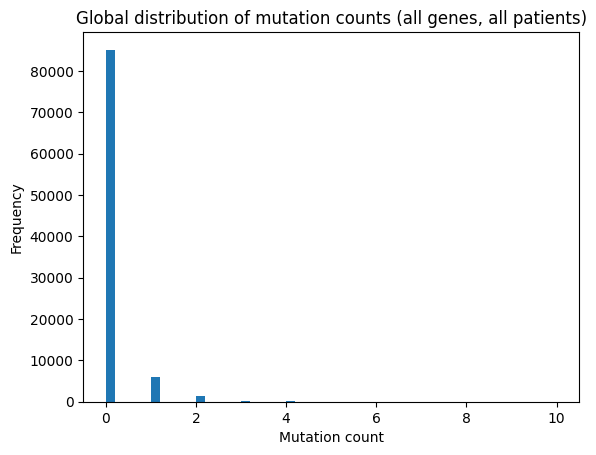

In [11]:
print(f'Zero proportion: {np.mean(vals == 0)}\nMean: {np.mean(vals)}\nMedian: {np.median(vals)}\nMax: {np.max(vals)}')
plt.hist(vals, bins=50)
plt.xlabel("Mutation count")
plt.ylabel("Frequency")
plt.title("Global distribution of mutation counts (all genes, all patients)")
plt.show()

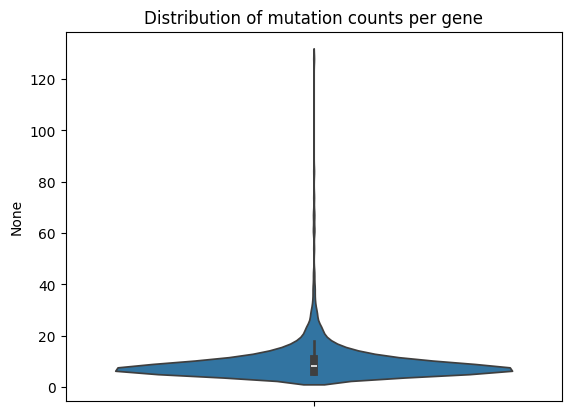

In [12]:
gene_nonzero_counts = mut_df.sum(axis=0)
sns.violinplot(y=gene_nonzero_counts)
plt.title("Distribution of mutation counts per gene")
plt.show()

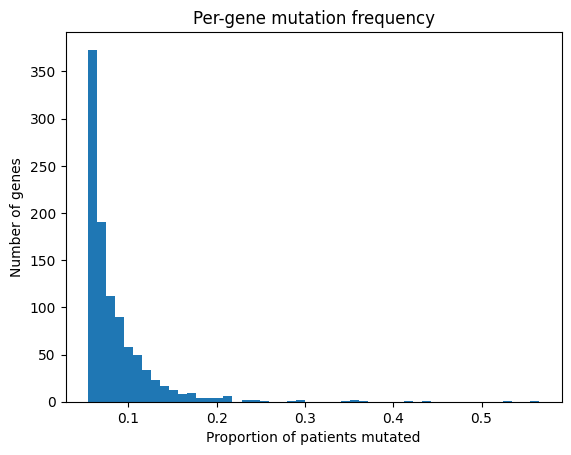

Median gene frequency: 0.06521739130434782


In [13]:
gene_freq = (mut_df > 0).mean(axis=0)
plt.hist(gene_freq, bins=50)
plt.xlabel("Proportion of patients mutated")
plt.ylabel("Number of genes")
plt.title("Per-gene mutation frequency")
plt.show()
print("Median gene frequency:", gene_freq.median())

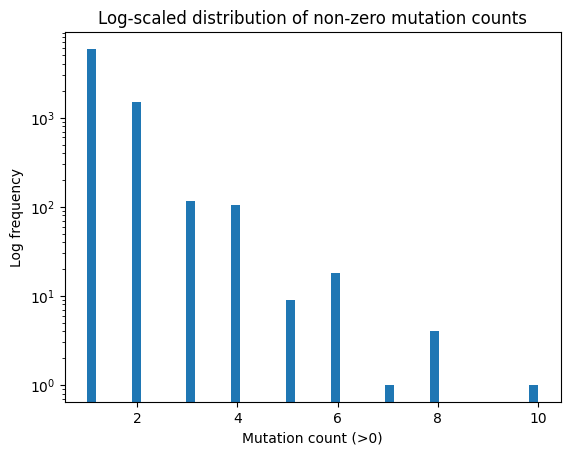

In [14]:
plt.hist(vals[vals > 0], bins=50)
plt.yscale('log')
plt.xlabel("Mutation count (>0)")
plt.ylabel("Log frequency")
plt.title("Log-scaled distribution of non-zero mutation counts")
plt.show()

In [15]:
print(np.quantile(vals, [0, 0.5, 0.9, 0.99, 0.999, 1.0]))
zero_fraction = (mut_df == 0).mean().mean()
print(f"Overall sparsity: {zero_fraction:.4f}")

[ 0.  0.  0.  2.  4. 10.]
Overall sparsity: 0.9175


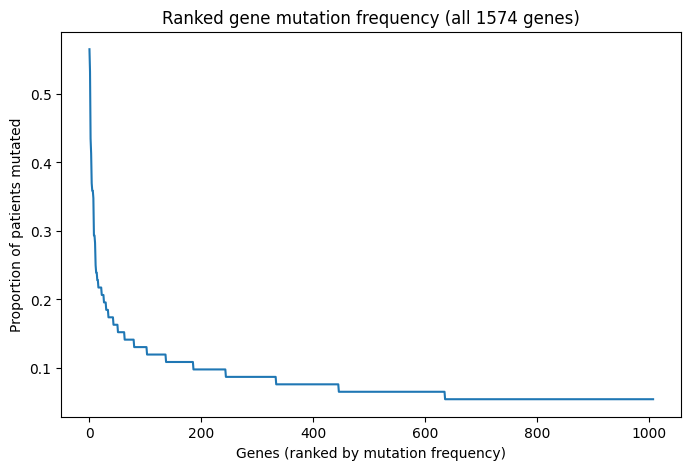

In [16]:
gene_freq = (mut_df > 0).mean(axis=0).sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.plot(range(len(gene_freq)), gene_freq.values)
plt.xlabel("Genes (ranked by mutation frequency)")
plt.ylabel("Proportion of patients mutated")
plt.title("Ranked gene mutation frequency (all 1574 genes)")
plt.show()

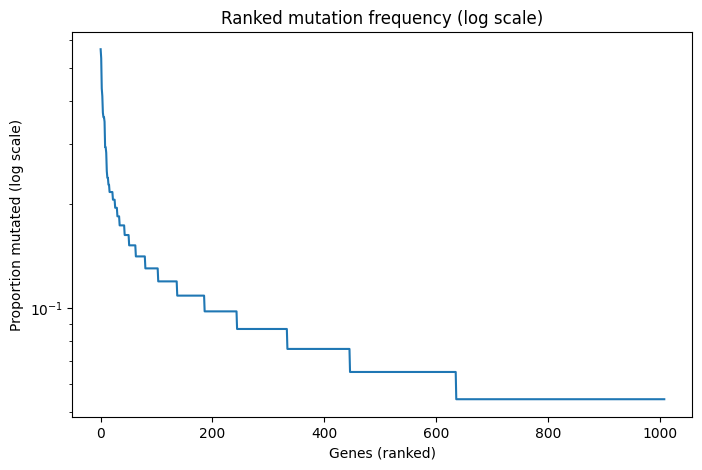

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(len(gene_freq)), gene_freq.values)
plt.yscale('log')
plt.xlabel("Genes (ranked)")
plt.ylabel("Proportion mutated (log scale)")
plt.title("Ranked mutation frequency (log scale)")
plt.show()

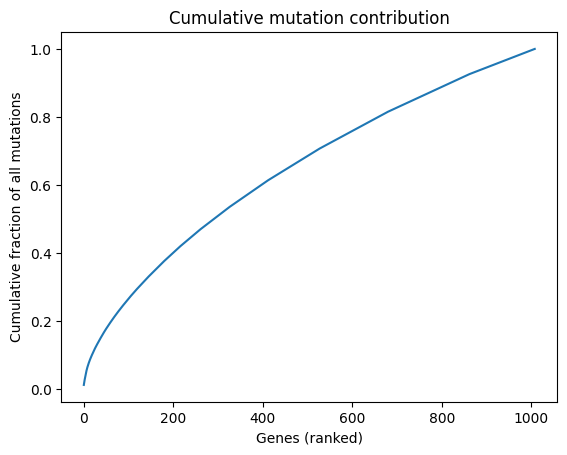

In [18]:
total_mut = mut_df.sum(axis=0).sort_values(ascending=False)
cumulative = total_mut.cumsum() / total_mut.sum()

plt.plot(cumulative.values)
plt.xlabel("Genes (ranked)")
plt.ylabel("Cumulative fraction of all mutations")
plt.title("Cumulative mutation contribution")
plt.show()